In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
import pandas as pd

In [2]:
# load the data
data = pd.read_csv('diabetes_dataset.csv')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [9]:
# One Hot Encoding for Categorical Variables
data = pd.get_dummies(data, drop_first=True)
# Splitting the dataset into features and target variable
X = data.drop('diagnosed_diabetes', axis=1)
y = data['diagnosed_diabetes']
# Splitting the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  
# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) 

#### Decision Tree with out Removeing Dibatic related fertures 

In [10]:
## Fit Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)
print("Decision Tree Classifier Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt)) 

Decision Tree Classifier Accuracy: 0.9994
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8077
           1       1.00      1.00      1.00     11923

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

Confusion Matrix:
 [[ 8070     7]
 [    5 11918]]


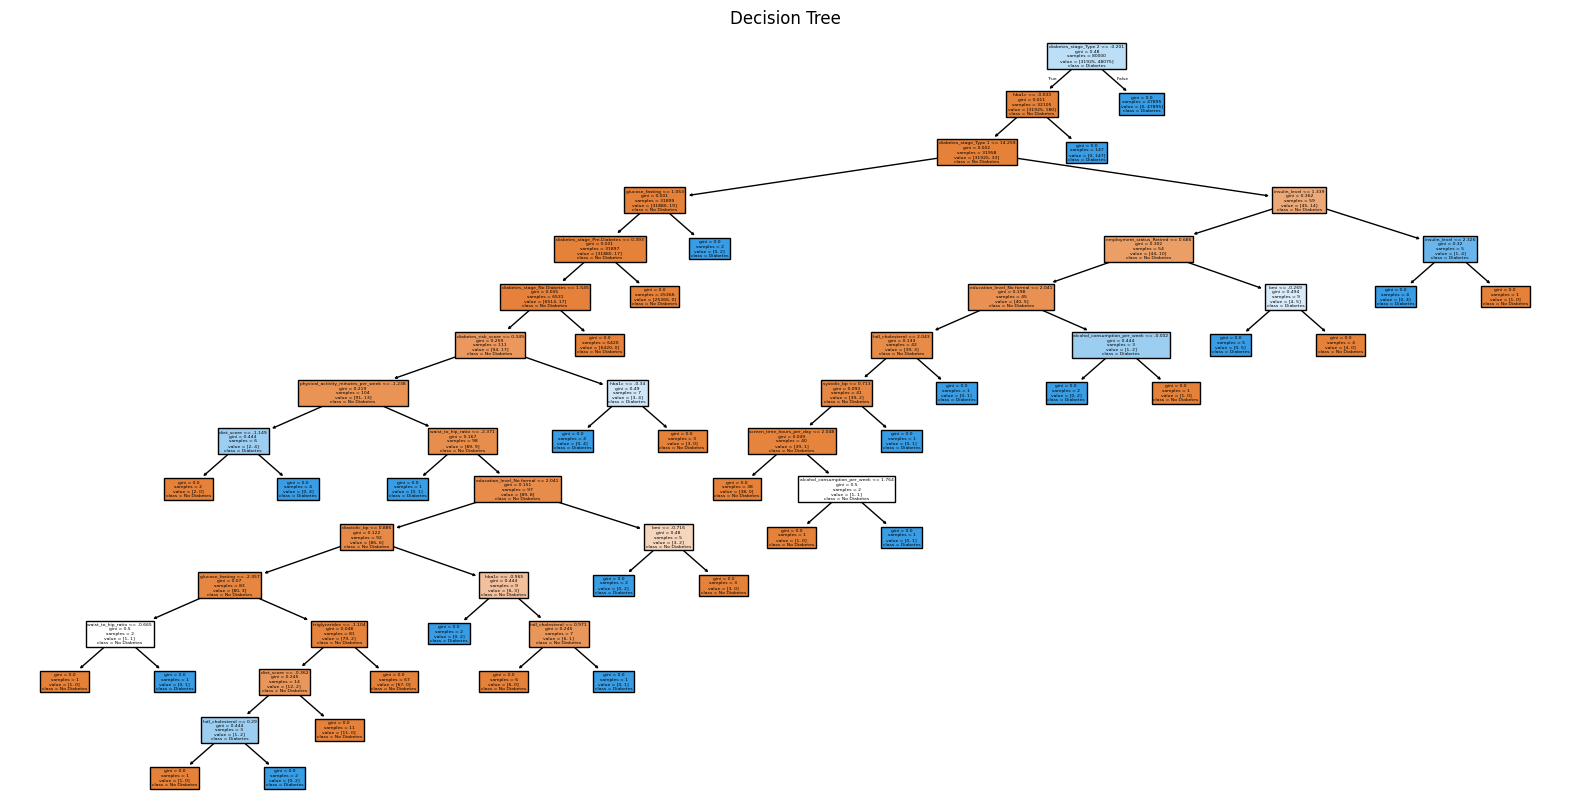

In [12]:
# plot the Decision Tree
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dt_classifier, filled=True, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'])
plt.title("Decision Tree")
plt.show() 

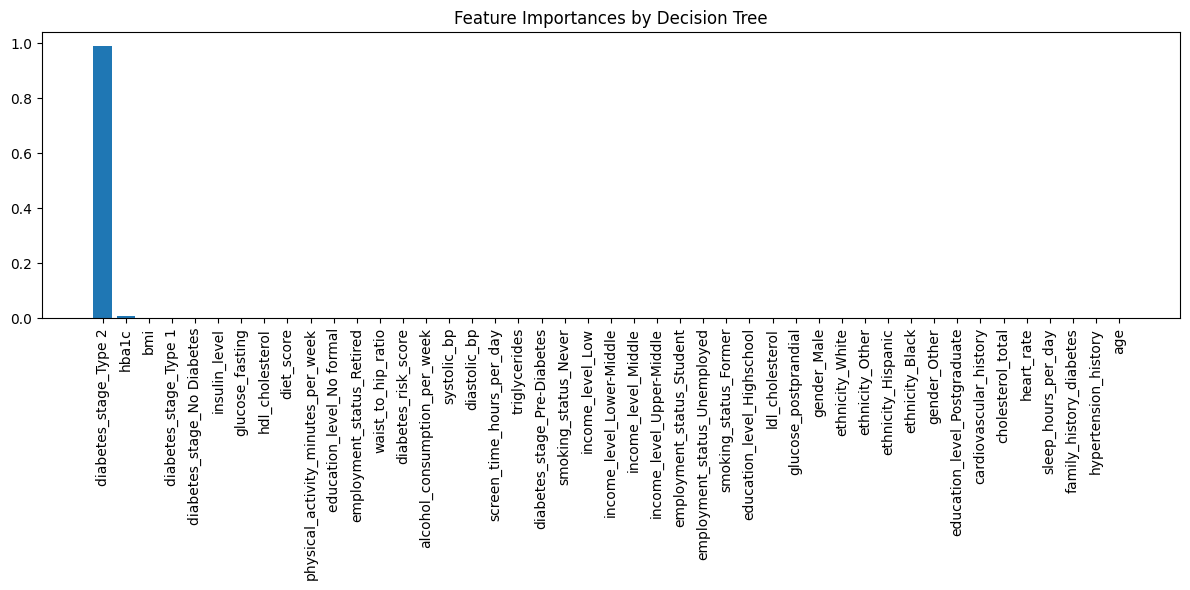

In [19]:
# Decision Tree Visualisation - Ferture Importance
importances = dt_classifier.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12,6))
plt.title("Feature Importances by Decision Tree")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

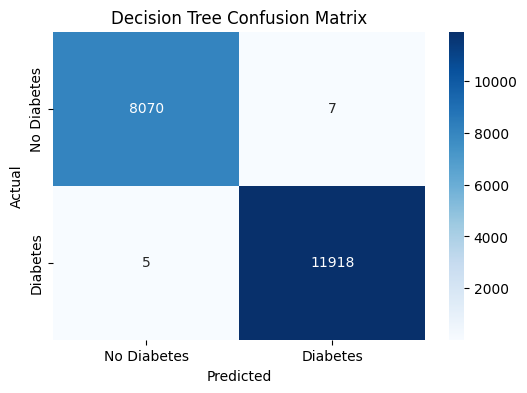

In [13]:
# Decision Tree Confusion Matrix Heatmap
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Decision Tree Confusion Matrix')
plt.show()

#### Random Forest with out Removeing Dibatic related fertures 

In [14]:
## Fit Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_test)
print("Random Forest Classifier Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Random Forest Classifier Accuracy: 0.99965
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8077
           1       1.00      1.00      1.00     11923

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

Confusion Matrix:
 [[ 8077     0]
 [    7 11916]]


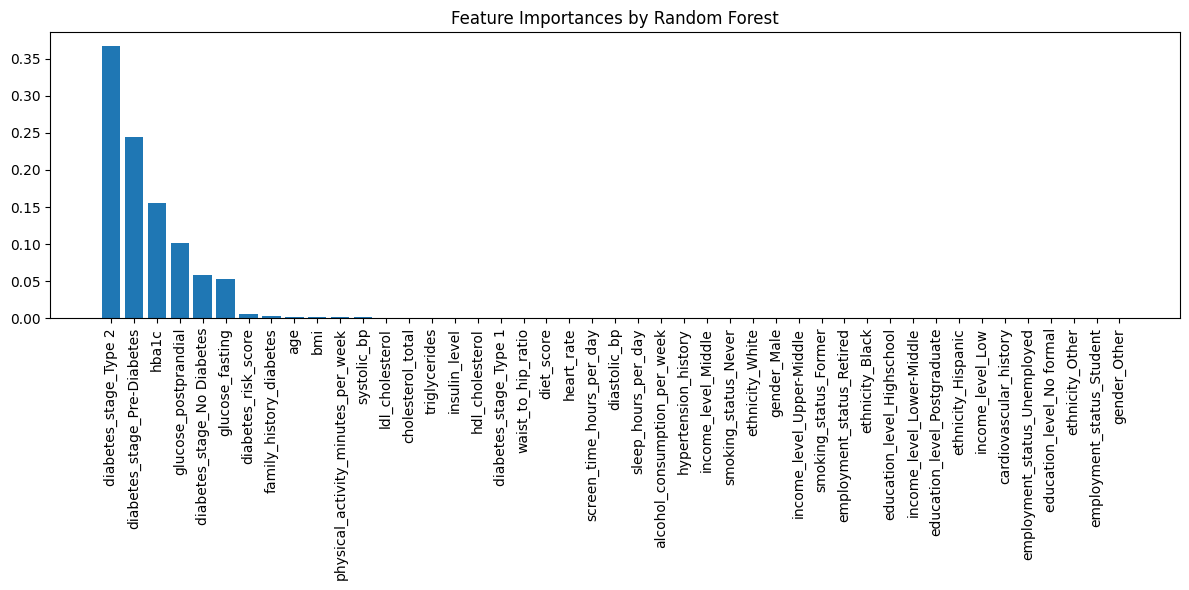

In [15]:
# Random Forest Visualization - Feature Importance
importances = rf_classifier.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12,6))
plt.title("Feature Importances by Random Forest")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.tight_layout()
plt.show() 

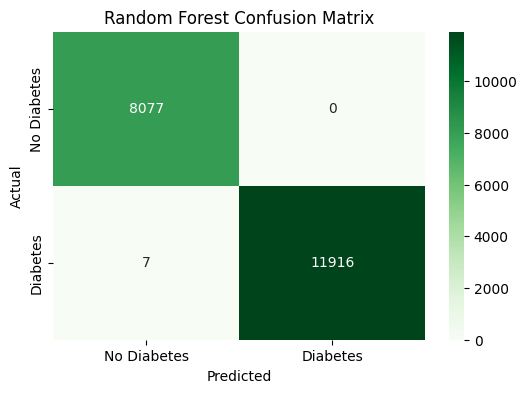

In [16]:
# Random Forest Confusion Matrix Heatmap
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Random Forest Confusion Matrix')
plt.show()

#### Decision Tree with  Removeing Dibatic related fertures 

In [ ]:
# Remove all the Fertures that has Dibetes in the Name and Re run the Rnadom Forest and Decision Tree Classifier
X_reduced = X.drop(columns=[col for col in X.columns if 'diabetes' in col.lower()])
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(X_reduced, y, test_size=0.2, random_state=42)  
X_train_reduced = scaler.fit_transform(X_train_reduced)
X_test_reduced = scaler.transform(X_test_reduced)   
# Re Fit Decision Tree Classifier
dt_classifier_reduced = DecisionTreeClassifier(random_state=42)
dt_classifier_reduced.fit(X_train_reduced, y_train_reduced)
y_pred_dt_reduced = dt_classifier_reduced.predict(X_test_reduced)
print("Reduced Decision Tree Classifier Accuracy:", accuracy_score(y_test_reduced, y_pred_dt_reduced))
print(classification_report(y_test_reduced, y_pred_dt_reduced))
print("Confusion Matrix:\n", confusion_matrix(y_test_reduced, y_pred_dt_reduced))  
 

Reduced Decision Tree Classifier Accuracy: 0.86395
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      8077
           1       0.88      0.89      0.89     11923

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000

Confusion Matrix:
 [[ 6662  1415]
 [ 1306 10617]]
Reduced Random Forest Classifier Accuracy: 0.9202
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      8077
           1       1.00      0.87      0.93     11923

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000

Confusion Matrix:
 [[ 8077     0]
 [ 1596 10327]]


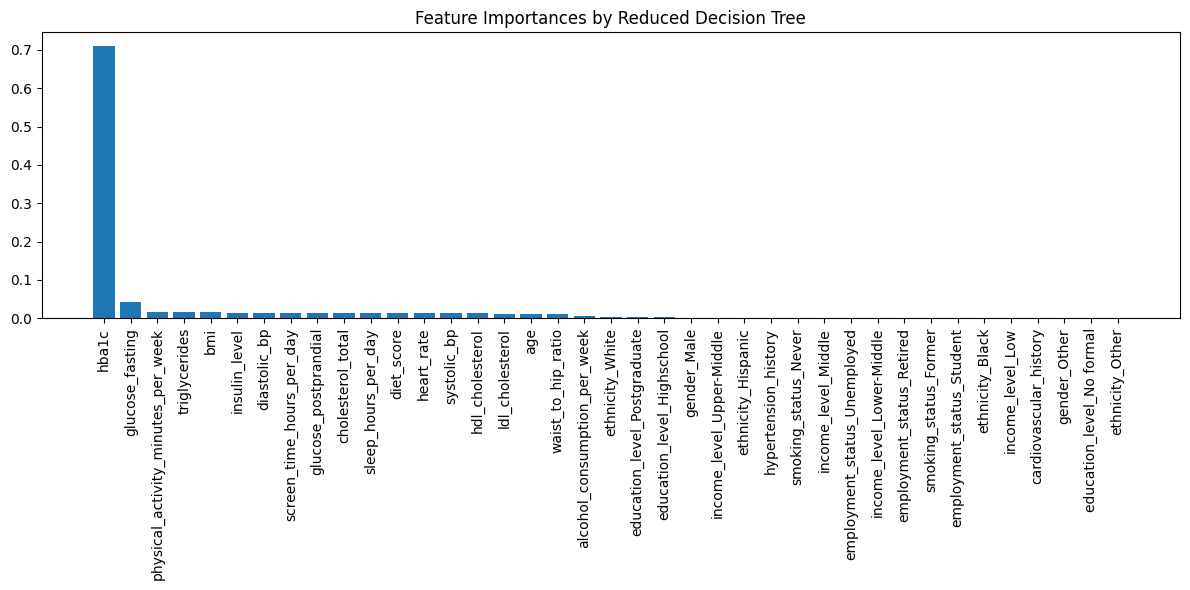

In [23]:
# Reduced Decision Tree Classifier visualisation - Ferture Importance
importances = dt_classifier_reduced.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12,6))
plt.title("Feature Importances by Reduced Decision Tree")
plt.bar(range(X_reduced.shape[1]), importances[indices], align='center')
plt.xticks(range(X_reduced.shape[1]), X_reduced.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

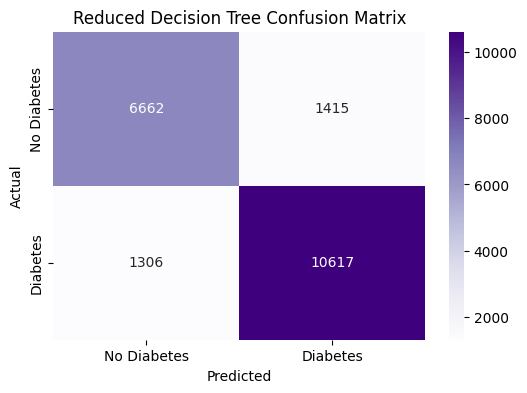

In [26]:
# Reduce Decision Tree Classifier Confusion Matrix Heatmap
cm_dt_reduced = confusion_matrix(y_test_reduced, y_pred_dt_reduced)
plt.figure(figsize=(6,4))
sns.heatmap(cm_dt_reduced, annot=True, fmt='d', cmap='Purples', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Reduced Decision Tree Confusion Matrix')
plt.show()

#### Random Forest with  Removeing Dibatic related fertures 

In [27]:
# Re Fit Random Forest Classifier
rf_classifier_reduced = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier_reduced.fit(X_train_reduced, y_train_reduced)
y_pred_rf_reduced = rf_classifier_reduced.predict(X_test_reduced)
print("Reduced Random Forest Classifier Accuracy:", accuracy_score(y_test_reduced, y_pred_rf_reduced))
print(classification_report(y_test_reduced, y_pred_rf_reduced))
print("Confusion Matrix:\n", confusion_matrix(y_test_reduced, y_pred_rf_reduced)) 

Reduced Random Forest Classifier Accuracy: 0.9202
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      8077
           1       1.00      0.87      0.93     11923

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000

Confusion Matrix:
 [[ 8077     0]
 [ 1596 10327]]


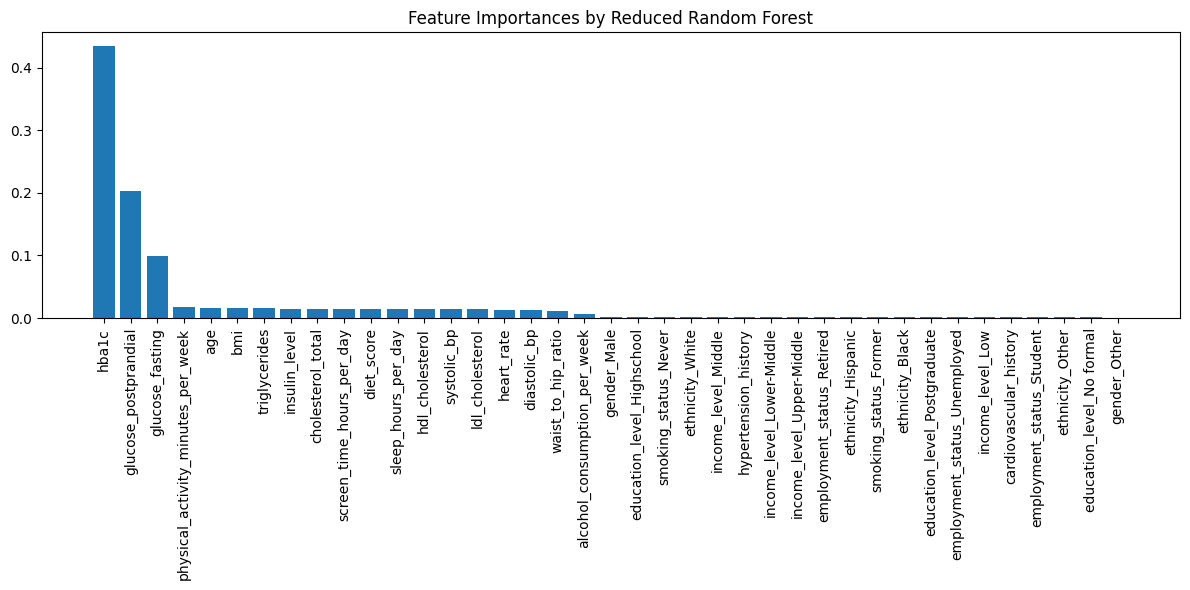

In [24]:
# Reduce Random Forest Classifier visualisation - Ferture Importance
importances = rf_classifier_reduced.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12,6))
plt.title("Feature Importances by Reduced Random Forest")
plt.bar(range(X_reduced.shape[1]), importances[indices], align='center')
plt.xticks(range(X_reduced.shape[1]), X_reduced.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

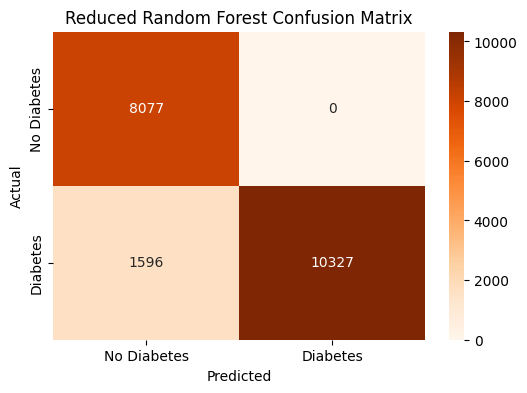

In [25]:
# Reduced Random Forest Classifier Confusion Matrix Heatmap
cm_rf_reduced = confusion_matrix(y_test_reduced, y_pred_rf_reduced)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf_reduced, annot=True, fmt='d', cmap='Oranges', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Reduced Random Forest Confusion Matrix')
plt.show()